# **Data Science**

**Grupo:**
- Miguel Manfré; RM564233
- Vitor Pallis; RM561962
- João Victor; RM563433
- Gabriel Speck; RM562513
- Brenda Thais; RM561258


# Contextualização do problema:

## Problema escolhido

### *Rastreamento orbital e comportamento de satélites*
Principalmente na distribuição de altitudes, inclinações e excentricidades, identificação de outliers (objetos com comportamento orbital atípico) e detecção de sinais de decaimento orbital ao longo do tempo.

## Relevância do problema

A gestão do tráfego espacial e a mitigação de detritos orbitais são cruciais para a sustentabilidade das operações espaciais. Entender a distribuição de órbitas, identificar satélites em risco de reentrada e detectar padrões de comportamento suporta decisões sobre prevenção de colisões, planejamento de janelas de lançamento, regulação de frequências e investimentos em políticas de mitigação.

## Relação com a economia espacial

Operadores comerciais (telecomunicações, observação da Terra, constelações IoT) dependem de alocação eficiente de órbitas e de previsões confiáveis para reduzir custos e riscos. Insights sobre concentrações orbitais, taxas de decaimento e distribuição por operador ajudam a direcionar investimentos, políticas de responsabilidade e serviços de monitoramento impactando diretamente receita,seguro e estratégias operacionais na economia espacial.

## Objetivo da análise

Obejetivo de aplicar estatística descritiva a dados públicos de um CSV do site KAGGLE para:

- Caracterizar distribuições de altitude, inclinação, excentricidade e período orbital.
- Quantificar variabilidade (desvio padrão, CV) e posição (Q1/Q2/Q3, percentis).
- Detectar outliers usando IQR e/ou Z-score e interpretar causas prováveis (decaimento, manobra, objetos incomuns).

Site referência:
https://www.kaggle.com/datasets/karnikakapoor/satellite-orbital-catalog

# Preparação dos Dados
Utilizaremos as bibliotecas em Python:
- Pandas: leitura, limpeza e manipulação de dados
- Numpy: operações numéricas e cálculo de medidas estatísticas.
- Matplotlib: visualizações estatísticas (histogramas, boxplots, scatter).

In [29]:
%pip install pandas; numpy; matplotlib; seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importação das bibliotecas

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Leitura dos Dados

In [31]:
df = pd.read_csv('./current_catalog.csv')
df.head()

,norad_id,name,object_type,satellite_constellation,altitude_km,altitude_category,orbital_band,congestion_risk,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,orbit_lifetime_category,mean_motion,epoch,data_source,snapshot_date,country,last_seen
0,900,CALSPHERE 1,PAYLOAD,Other,975.928822,Low LEO,LEO-Polar,LOW,90.2236,0.002533,2024,0,<1yr,13.766118,2026-06-06 12:07:29.114112,celestrak,2026-06-06,US,2026-06-06
1,902,CALSPHERE 2,PAYLOAD,Other,1061.609076,Mid LEO,LEO-Polar,LOW,90.2377,0.001656,2024,0,<1yr,13.528997,2026-06-06 01:48:16.784064,celestrak,2026-06-06,US,2026-06-06
2,1361,LCS 1,PAYLOAD,Other,2787.867006,High LEO,MEO,LOW,32.1368,0.001240,2024,1,<1yr,9.893107,2026-06-05 11:00:01.893600,celestrak,2026-06-06,US,2026-06-06
3,1512,TEMPSAT 1,PAYLOAD,Other,1133.239326,Mid LEO,LEO-Polar,HIGH,89.9995,0.006763,2024,0,<1yr,13.335935,2026-06-06 11:36:44.059392,celestrak,2026-06-06,US,2026-06-06
4,1520,CALSPHERE 4A,PAYLOAD,Other,1123.182767,Mid LEO,LEO-Polar,HIGH,89.8976,0.007130,2024,0,<1yr,13.362762,2026-06-06 09:00:02.100384,celestrak,2026-06-06,US,2026-06-06


## Inspeção Estrutural

In [32]:
df.shape

(16188, 19)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16188 entries, 0 to 16187
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   norad_id                 16188 non-null  int64  
 1   name                     16188 non-null  str    
 2   object_type              16187 non-null  str    
 3   satellite_constellation  16188 non-null  str    
 4   altitude_km              16188 non-null  float64
 5   altitude_category        16188 non-null  str    
 6   orbital_band             16188 non-null  str    
 7   congestion_risk          16188 non-null  str    
 8   inclination              16188 non-null  float64
 9   eccentricity             16188 non-null  float64
 10  launch_year_estimate     16188 non-null  int64  
 11  days_in_orbit_estimate   16188 non-null  int64  
 12  orbit_lifetime_category  16188 non-null  str    
 13  mean_motion              16188 non-null  float64
 14  epoch                    16188 no

## Resumo estatístico

Medidas de tendência central 

- média 
- mediana

Medidas de dispersão

- amplitude
- desvio padrão(std)

Medidas posicionais 

- Q1 
- Q2 
- Q3 
- percentis 

In [47]:
df.describe(percentiles=[0.05,0.25,0.5,0.75,0.95]).T

,count,mean,min,5%,25%,50%,75%,95%,max,std
norad_id,16188.0,58000.102854,900.0,40971.35,53206.75,59610.5,65064.25,68469.65,69328.0,8924.268565
altitude_km,16188.0,2167.622194,136.628422,346.813331,468.82207,483.051899,558.821574,8065.886404,235127.946482,7470.959838
inclination,16188.0,61.198411,0.0017,39.990475,43.0044,53.1601,87.8952,97.650255,150.1347,24.178475
eccentricity,16188.0,0.002713,0.000002,0.000063,0.000117,0.000164,0.000326,0.001451,0.904297,0.039362
launch_year_estimate,16188.0,2023.992958,2023.0,2024.0,2024.0,2024.0,2024.0,2024.0,2024.0,0.083625
days_in_orbit_estimate,16188.0,0.582468,-2.0,0.0,0.0,0.0,1.0,2.0,30.0,1.37539
mean_motion,16188.0,14.402051,0.073149,5.001157,15.026198,15.275791,15.323436,15.742335,16.510286,3.105099
epoch,16188,2026-06-02 06:50:29.682375,2025-11-06 20:24:17.841600,2026-06-01 16:06:33.221894,2026-06-05 10:29:12.293160,2026-06-05 20:45:33.843024,2026-06-06 03:17:46.147272,2026-06-06 08:00:13.000320,2026-06-07 19:09:26.033472,NaN


Medidas de dispersão
- variância

In [48]:
df.var(numeric_only=True)

norad_id                  7.964257e+07
altitude_km               5.581524e+07
inclination               5.845987e+02
eccentricity              1.549348e-03
launch_year_estimate      6.993092e-03
days_in_orbit_estimate    1.891697e+00
mean_motion               9.641640e+00
dtype: float64

Medidadas de dispersão
- Coeficiente de variação (CV)

In [53]:
cv = df.std(numeric_only=True, ddof=0) / df.mean(numeric_only=True)
cv_percent = cv * 100
cv_percent

norad_id                    15.386167
altitude_km                344.650885
inclination                 39.507118
eccentricity              1451.044697
launch_year_estimate         0.004132
days_in_orbit_estimate     236.123912
mean_motion                 21.559451
dtype: float64

Medidas de tendência central 

- Moda

In [35]:
df.describe(include='object').T

C:\Users\User\AppData\Local\Temp\ipykernel_27520\1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
name,16188,16184,ELECTRON KICK STAGE R/B,2
object_type,16187,4,PAYLOAD,15574
satellite_constellation,16188,6,Starlink Gen 1,10792
altitude_category,16188,7,Very Low LEO,9618
orbital_band,16188,8,LEO-Inclined,6798
congestion_risk,16188,3,HIGH,13092
orbit_lifetime_category,16188,2,<1yr,16186
epoch,16188,15240,2026-06-06 06:00:02.000160,538
data_source,16188,1,celestrak,16188
snapshot_date,16188,168,2026-06-06,15630


Análise de outliers 

- IQR 
- Z-Score

In [68]:
variaveis = ['altitude_km', 'inclination', 'eccentricity', 'mean_motion']

resultado_iqr = []

for col in variaveis:
    serie = pd.to_numeric(df[col], errors='coerce').dropna()
    
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    
    resultado_iqr.append({
        'variavel': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'qtd_outliers': outliers.shape[0]
    })

tabela_iqr = pd.DataFrame(resultado_iqr)
tabela_iqr


,variavel,q1,q3,iqr,limite_inferior,limite_superior,qtd_outliers
0,altitude_km,468.822070,558.821574,89.999504,333.822815,693.820830,3168
1,inclination,43.004400,87.895200,44.890800,-24.331800,155.231400,0
2,eccentricity,0.000117,0.000326,0.000209,-0.000197,0.000640,2371
3,mean_motion,15.026198,15.323436,0.297238,14.580341,15.769293,3174


In [73]:
variaveis = ['altitude_km', 'inclination', 'eccentricity', 'mean_motion']

resultado_z = []

for col in variaveis:
    serie = pd.to_numeric(df[col], errors='coerce').dropna()
    
    z = (serie - serie.mean()) / serie.std(ddof=1)
    outliers_z = serie[np.abs(z) > 3]

    resultado_z.append({
        'variavel': col,
        'qtd_outliers_z': outliers_z.shape[0]
    })

tabela_z = pd.DataFrame(resultado_z)
tabela_z

,variavel,qtd_outliers_z
0,altitude_km,630
1,inclination,5
2,eccentricity,53
3,mean_motion,826


## Valores ausentes

In [36]:
missing = df.isnull().sum()
missing_percent = missing / len(df) * 100
pd.concat([missing, missing_percent], axis=1, keys=['missing','percent'])

,missing,percent
norad_id,0,0.000000
name,0,0.000000
object_type,1,0.006177
satellite_constellation,0,0.000000
altitude_km,0,0.000000
altitude_category,0,0.000000
orbital_band,0,0.000000
congestion_risk,0,0.000000
inclination,0,0.000000
eccentricity,0,0.000000


## Duplicatas e identificadores

In [37]:
df[df.duplicated(keep=False)].head()
df['norad_id'].nunique(), df['norad_id'].value_counts().head()

(16188,
 norad_id
 900     1
 902     1
 1361    1
 1512    1
 1520    1
 Name: count, dtype: int64)

## Valores inconsistentes

In [38]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['epoch'] = pd.to_datetime(df['epoch'], errors='coerce')

## Ranges e outliers iniciais

In [39]:
df['name'].value_counts().head(10)

name
ELECTRON KICK STAGE R/B    2
OTTER                      2
BOTAN                      2
CMS-03 (GSAT-7R)           2
CALSPHERE 1                1
CALSPHERE 2                1
LCS 1                      1
TEMPSAT 1                  1
CALSPHERE 4A               1
OPS 5712 (P/L 160)         1
Name: count, dtype: int64

## Correlação entre as variáveis

<Axes: >

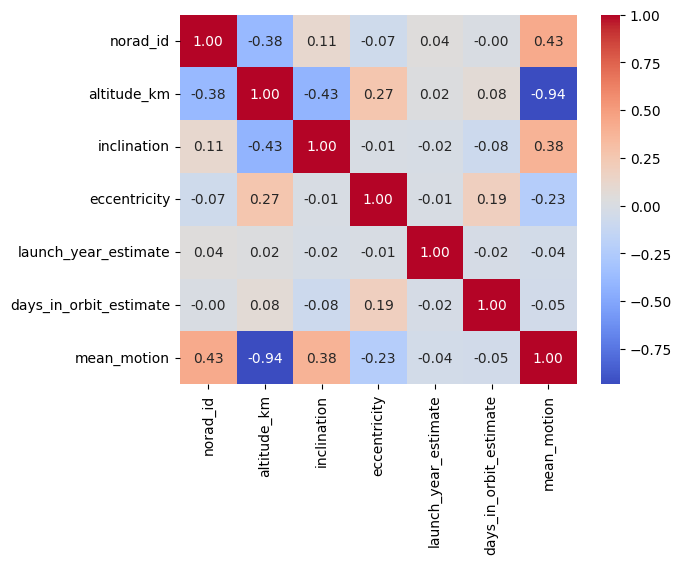

In [40]:
corr = df.select_dtypes('number').corr()
import seaborn as sns; import matplotlib.pyplot as plt
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

In [41]:
rows_many_null = df[df.isnull().mean(axis=1) > 0.5]
cols_many_null = df.columns[df.isnull().mean() > 0.5]

In [42]:
df_clean = df.copy()  # após limpeza
df_clean.to_csv('df_satelites_limpo.csv', index=False)

## Grafico de barras
Quantidade de satélites por país

In [43]:
df['country'].value_counts().head(10)

country
US     12157
PRC     1406
UK       701
CIS      293
TBD      286
JPN      125
IT        87
FR        74
IND       74
ESA       70
Name: count, dtype: int64

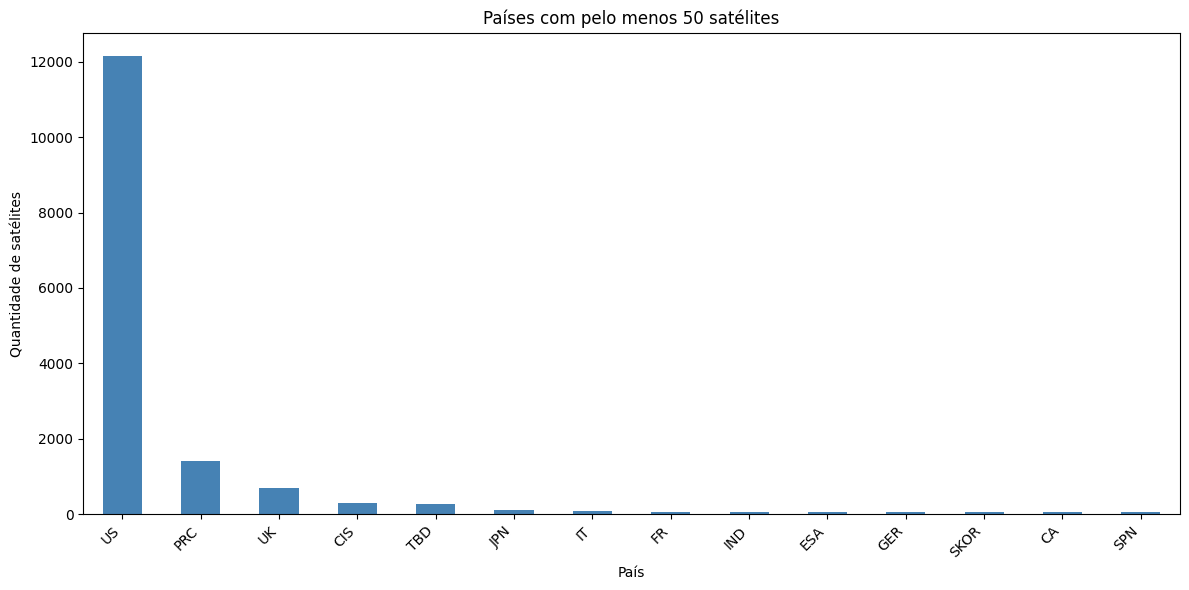

In [44]:
# Contagem de satélites por país
contagem_pais = df['country'].value_counts()

# Defina o mínimo para aparecer no gráfico
min_sat = 50  # ajuste para 5, 10, 20, 50...

# Filtra países com pelo menos min_sat satélites
contagem_filtrada = contagem_pais[contagem_pais >= min_sat].sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(12, 6))
contagem_filtrada.plot(kind='bar', color='steelblue')
plt.title(f'Países com pelo menos {min_sat} satélites')
plt.xlabel('País')
plt.ylabel('Quantidade de satélites')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()